# Bay Area Multifamily: Price Trend Forecasting

**Goal:** Forecast 12-month price trends for Bay Area multifamily submarkets using Zillow Home Value Index time series data.

**Methods:**
1. Time series decomposition (trend + seasonality)
2. SARIMA model for submarket-level forecasts
3. Macro factor regression (mortgage rates, unemployment → price impact)

**Output:** 12-month price forecasts with confidence intervals for top Bay Area submarkets.

---

> *Note: ZHVI is a repeat-sales index for all homes — multifamily-specific price data at zip level is not publicly available. ZHVI directionally tracks MF values and is the standard proxy used in market analysis.*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

DATA = Path('../data/raw')
OUT  = Path('../outputs')
(OUT / 'charts').mkdir(exist_ok=True)
(OUT / 'tables').mkdir(exist_ok=True)

## 1. Build time series dataset

In [2]:
zhvi = pd.read_csv(DATA / 'zillow_zhvi_zip.csv', dtype={'RegionName': str})

meta_cols = ['RegionID','SizeRank','RegionName','RegionType','StateName','State','City','Metro','CountyName']
date_cols = sorted([c for c in zhvi.columns if c not in meta_cols])

# Use data from 2015 onward — enough history for SARIMA, avoids pre-GFC noise
date_cols_recent = [c for c in date_cols if c >= '2015-01-01']

print(f'ZHVI: {len(zhvi)} Bay Area zip codes')
print(f'Time series: {date_cols_recent[0]} → {date_cols_recent[-1]} ({len(date_cols_recent)} months)')
print(f'\nCounty breakdown:')
print(zhvi['CountyName'].value_counts())

ZHVI: 274 Bay Area zip codes
Time series: 2015-01-31 → 2026-04-30 (136 months)

County breakdown:
CountyName
Santa Clara County      56
Alameda County          47
Contra Costa County     39
Sonoma County           32
San Mateo County        28
San Francisco County    26
Marin County            26
Solano County           12
Napa County              8
Name: count, dtype: int64


In [3]:
# Melt to long format for analysis
zhvi_long = zhvi[meta_cols + date_cols_recent].melt(
    id_vars=meta_cols,
    var_name='date',
    value_name='zhvi'
)
zhvi_long['date'] = pd.to_datetime(zhvi_long['date'])
zhvi_long['zip_code'] = zhvi_long['RegionName']

# County-level aggregate (mean of zip ZHVIs)
county_ts = zhvi_long.groupby(['date','CountyName'])['zhvi'].mean().reset_index()
county_ts = county_ts.sort_values(['CountyName','date'])

print(f'Long format: {len(zhvi_long):,} rows')

Long format: 37,264 rows


## 2. Bay Area price history overview

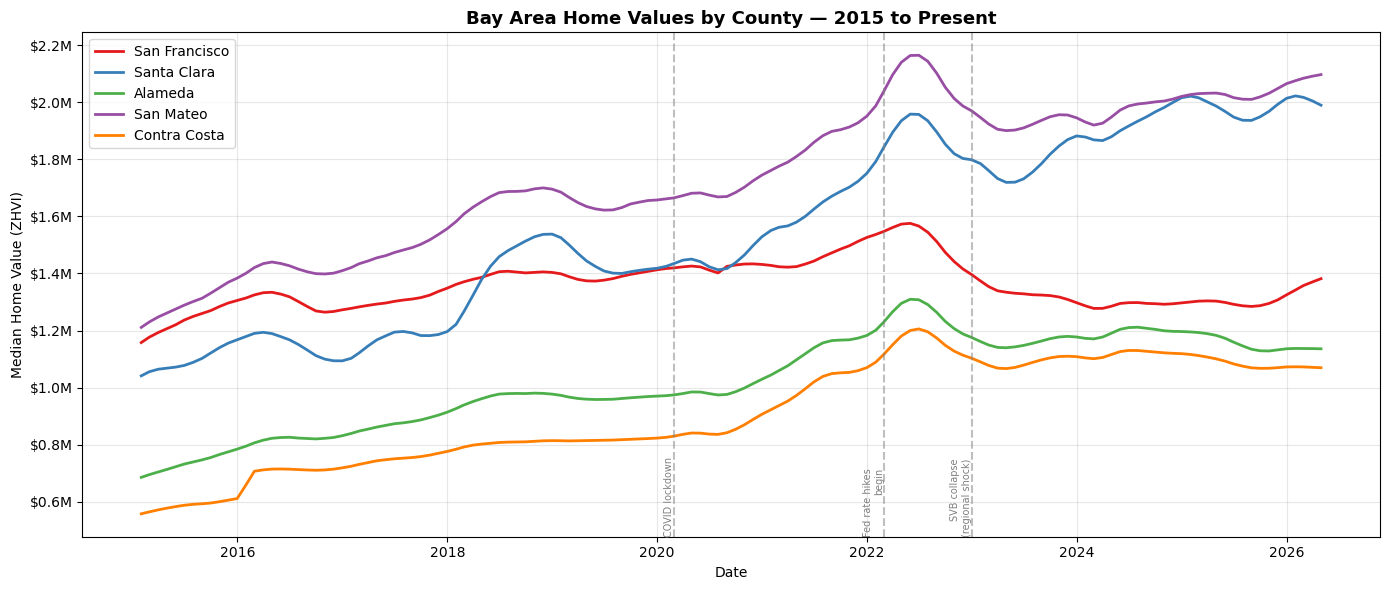

In [4]:
key_counties = ['San Francisco County','Santa Clara County','Alameda County',
                'San Mateo County','Contra Costa County']

fig, ax = plt.subplots(figsize=(14, 6))

colors = ['#e41a1c','#377eb8','#4daf4a','#984ea3','#ff7f00']
for county, color in zip(key_counties, colors):
    ts = county_ts[county_ts['CountyName'] == county]
    if ts.empty:
        continue
    ax.plot(ts['date'], ts['zhvi'] / 1e6, label=county.replace(' County',''), 
            color=color, linewidth=2)

# Key events
events = {
    '2020-03': ('COVID lockdown', 0.3),
    '2022-03': ('Fed rate hikes\nbegin', 0.3),
    '2023-01': ('SVB collapse\n(regional shock)', 0.15),
}
for date_str, (label, ypos) in events.items():
    ax.axvline(pd.Timestamp(date_str), color='gray', linestyle='--', alpha=0.5)
    ax.text(pd.Timestamp(date_str), ax.get_ylim()[0] if ax.get_ylim()[0] > 0 else 0.5, 
            label, fontsize=7, rotation=90, va='bottom', ha='right', color='gray')

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.1f}M'))
ax.set_xlabel('Date')
ax.set_ylabel('Median Home Value (ZHVI)')
ax.set_title('Bay Area Home Values by County — 2015 to Present', fontweight='bold', fontsize=13)
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT / 'charts/county_price_history.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Time series decomposition

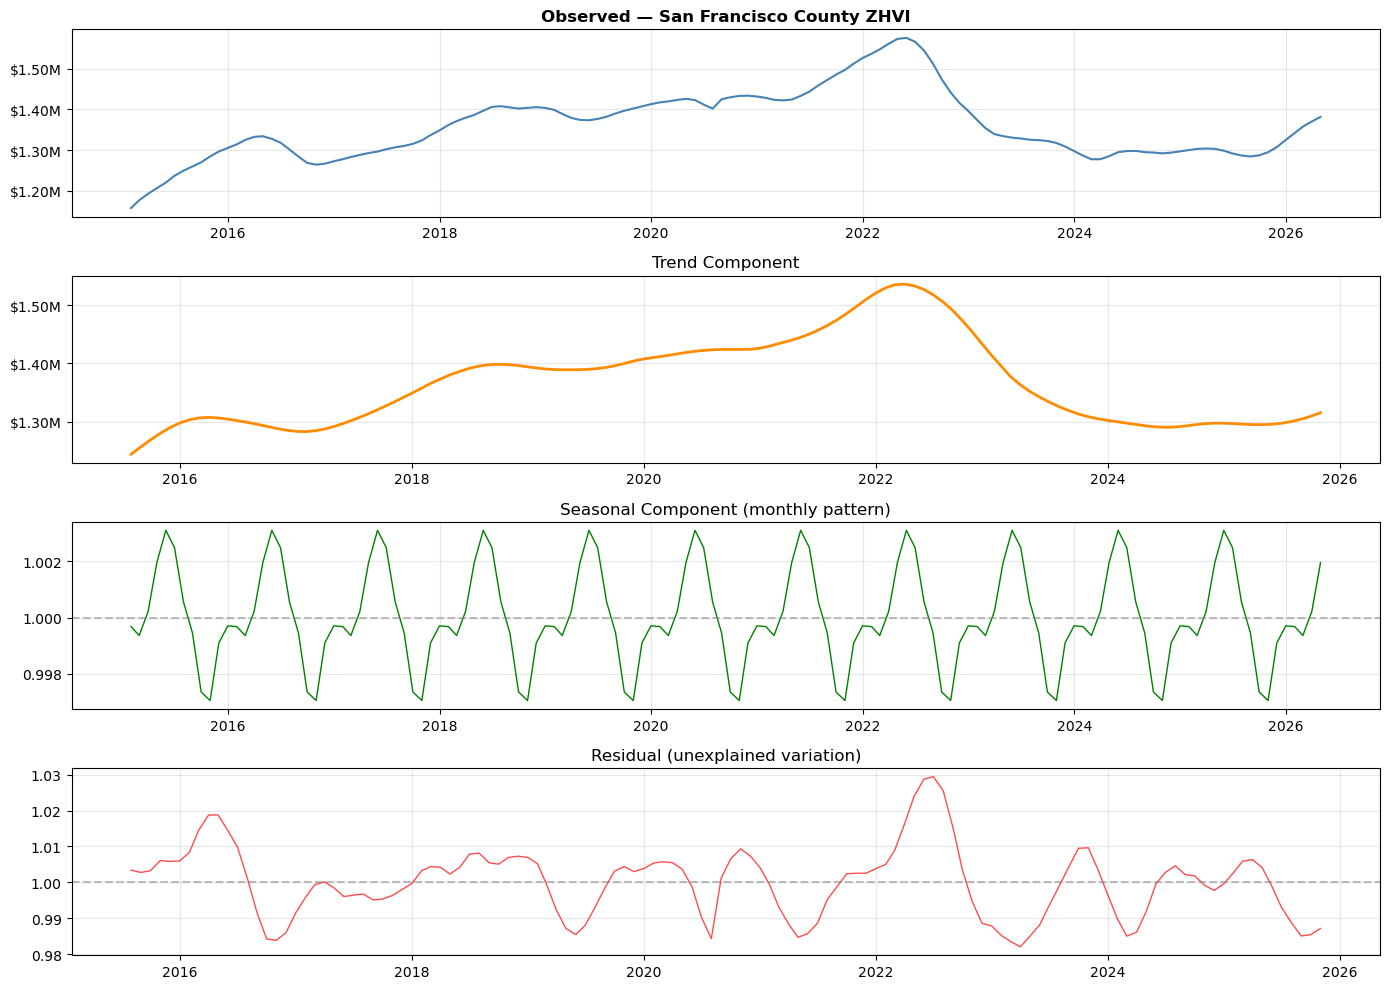

ADF test on MoM returns: p-value = 0.0026
→ Series is stationary in returns


In [5]:
# Decompose SF County ZHVI into trend + seasonal + residual
sf_ts = county_ts[county_ts['CountyName'] == 'San Francisco County'].copy()
sf_ts = sf_ts.set_index('date')['zhvi'].dropna()

decomp = seasonal_decompose(sf_ts, model='multiplicative', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))

axes[0].plot(sf_ts, color='steelblue', linewidth=1.5)
axes[0].set_title('Observed — San Francisco County ZHVI', fontweight='bold')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.2f}M'))

axes[1].plot(decomp.trend, color='darkorange', linewidth=2)
axes[1].set_title('Trend Component')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.2f}M'))

axes[2].plot(decomp.seasonal, color='green', linewidth=1)
axes[2].set_title('Seasonal Component (monthly pattern)')
axes[2].axhline(1, color='gray', linestyle='--', alpha=0.5)

axes[3].plot(decomp.resid, color='red', linewidth=1, alpha=0.7)
axes[3].set_title('Residual (unexplained variation)')
axes[3].axhline(1, color='gray', linestyle='--', alpha=0.5)

for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT / 'charts/sf_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

# Stationarity test
adf_result = adfuller(sf_ts.pct_change().dropna())
print(f'ADF test on MoM returns: p-value = {adf_result[1]:.4f}')
print('→ Series is stationary in returns' if adf_result[1] < 0.05 else '→ Non-stationary in returns')

## 4. SARIMA forecasting by county

In [6]:
def fit_sarima_forecast(ts: pd.Series, county_name: str, n_forecast: int = 12):
    """
    Fit SARIMA(1,1,1)(1,1,1,12) and return forecast + confidence intervals.
    Using a light model (1,1,1) to avoid overfitting on ~120 months of data.
    """
    ts_clean = ts.dropna()
    if len(ts_clean) < 36:
        return None
    
    # Fit on last 7 years of data
    ts_fit = ts_clean[ts_clean.index >= '2018-01-01']
    
    model = SARIMAX(
        ts_fit,
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, 12),
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    result = model.fit(disp=False)
    
    forecast = result.get_forecast(steps=n_forecast)
    forecast_mean = forecast.predicted_mean
    conf_int = forecast.conf_int(alpha=0.20)  # 80% CI for investment planning
    
    return {
        'ts_fit': ts_fit,
        'forecast_mean': forecast_mean,
        'conf_int': conf_int,
        'aic': result.aic,
        'result': result,
    }

forecasts = {}
for county in key_counties:
    ts = county_ts[county_ts['CountyName'] == county].set_index('date')['zhvi']
    print(f'Fitting {county}...')
    out = fit_sarima_forecast(ts, county)
    if out:
        forecasts[county] = out
        latest_val = out['ts_fit'].iloc[-1]
        forecast_12m = out['forecast_mean'].iloc[-1]
        chg = (forecast_12m / latest_val - 1) * 100
        print(f'  AIC: {out["aic"]:.1f} | Forecast 12m: {chg:+.1f}%')
    else:
        print(f'  Insufficient data')

Fitting San Francisco County...


  AIC: 1521.9 | Forecast 12m: +6.5%
Fitting Santa Clara County...


  AIC: 1565.2 | Forecast 12m: -1.0%
Fitting Alameda County...


  AIC: 1480.4 | Forecast 12m: -1.2%
Fitting San Mateo County...


  AIC: 1561.6 | Forecast 12m: +4.4%
Fitting Contra Costa County...


  AIC: 1458.5 | Forecast 12m: +0.4%


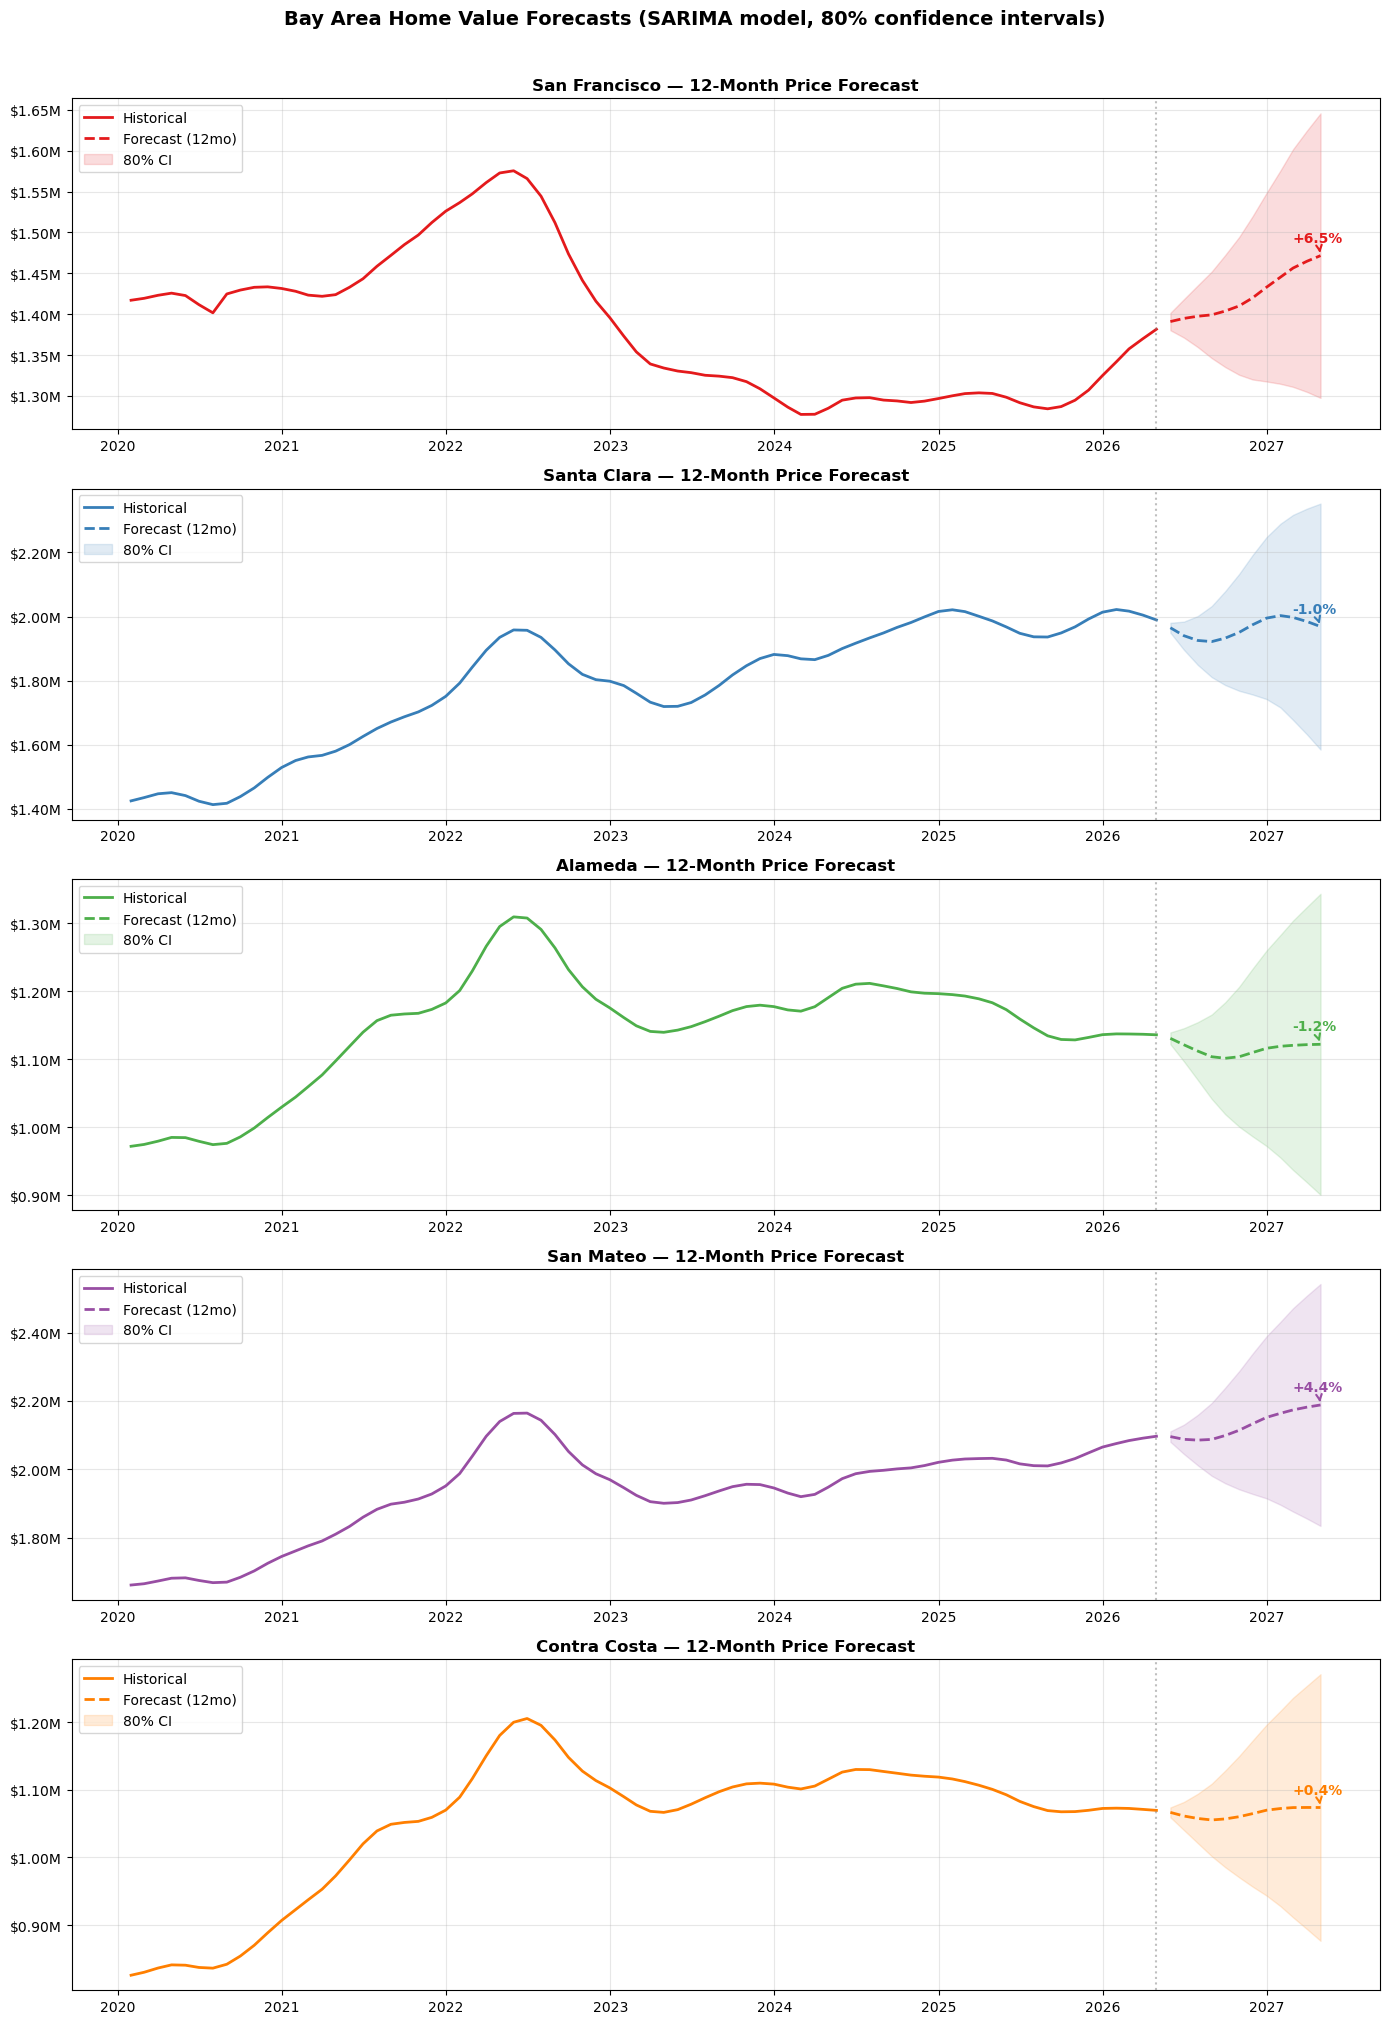

In [7]:
fig, axes = plt.subplots(len(forecasts), 1, figsize=(14, 4 * len(forecasts)))
if len(forecasts) == 1:
    axes = [axes]

colors = ['#e41a1c','#377eb8','#4daf4a','#984ea3','#ff7f00']

for ax, (county, data), color in zip(axes, forecasts.items(), colors):
    ts_plot = data['ts_fit']['2020-01-01':]
    fcast = data['forecast_mean']
    ci = data['conf_int']
    
    # Historical
    ax.plot(ts_plot.index, ts_plot.values / 1e6, color=color, linewidth=2, label='Historical')
    
    # Forecast
    ax.plot(fcast.index, fcast.values / 1e6, color=color, linewidth=2, 
            linestyle='--', label='Forecast (12mo)')
    
    # Confidence interval
    ax.fill_between(
        ci.index,
        ci.iloc[:, 0] / 1e6,
        ci.iloc[:, 1] / 1e6,
        alpha=0.15, color=color, label='80% CI'
    )
    
    # Annotate forecast change
    latest = ts_plot.iloc[-1]
    forecast_end = fcast.iloc[-1]
    chg = (forecast_end / latest - 1) * 100
    ax.annotate(
        f'{chg:+.1f}%',
        xy=(fcast.index[-1], forecast_end / 1e6),
        xytext=(-20, 10), textcoords='offset points',
        fontsize=10, fontweight='bold', color=color,
        arrowprops=dict(arrowstyle='->', color=color, lw=1.5)
    )
    
    ax.axvline(ts_plot.index[-1], color='gray', linestyle=':', alpha=0.5)
    ax.set_title(county.replace(' County','') + ' — 12-Month Price Forecast', fontweight='bold')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.2f}M'))
    ax.legend(loc='upper left')
    ax.grid(alpha=0.3)

plt.suptitle('Bay Area Home Value Forecasts (SARIMA model, 80% confidence intervals)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUT / 'charts/price_forecasts.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Forecast summary table

In [8]:
rows = []
for county, data in forecasts.items():
    ts = data['ts_fit']
    fcast = data['forecast_mean']
    ci = data['conf_int']
    
    current = ts.iloc[-1]
    f3m = fcast.iloc[2] if len(fcast) > 2 else np.nan
    f6m = fcast.iloc[5] if len(fcast) > 5 else np.nan
    f12m = fcast.iloc[-1]
    ci_low = ci.iloc[-1, 0]
    ci_high = ci.iloc[-1, 1]
    
    rows.append({
        'County': county.replace(' County',''),
        'Current Value': f'${current/1e6:.3f}M',
        '3mo Forecast': f'${f3m/1e6:.3f}M' if not np.isnan(f3m) else '-',
        '6mo Forecast': f'${f6m/1e6:.3f}M' if not np.isnan(f6m) else '-',
        '12mo Forecast': f'${f12m/1e6:.3f}M',
        '12mo Chg': f'{(f12m/current - 1)*100:+.1f}%',
        '80% CI (Low)': f'${ci_low/1e6:.3f}M',
        '80% CI (High)': f'${ci_high/1e6:.3f}M',
    })

forecast_table = pd.DataFrame(rows)
forecast_table.to_csv(OUT / 'tables/price_forecasts_12mo.csv', index=False)
print('12-Month Price Forecast Summary')
print('=' * 80)
display(forecast_table)

12-Month Price Forecast Summary


,County,Current Value,3mo Forecast,6mo Forecast,12mo Forecast,12mo Chg,80% CI (Low),80% CI (High)
0,San Francisco,$1.382M,$1.398M,$1.410M,$1.472M,+6.5%,$1.298M,$1.646M
1,Santa Clara,$1.989M,$1.925M,$1.951M,$1.969M,-1.0%,$1.585M,$2.353M
2,Alameda,$1.136M,$1.112M,$1.104M,$1.122M,-1.2%,$0.900M,$1.344M
3,San Mateo,$2.097M,$2.085M,$2.114M,$2.188M,+4.4%,$1.834M,$2.542M
4,Contra Costa,$1.070M,$1.058M,$1.060M,$1.074M,+0.4%,$0.877M,$1.271M


## 6. Metro-level transaction trends (Redfin)

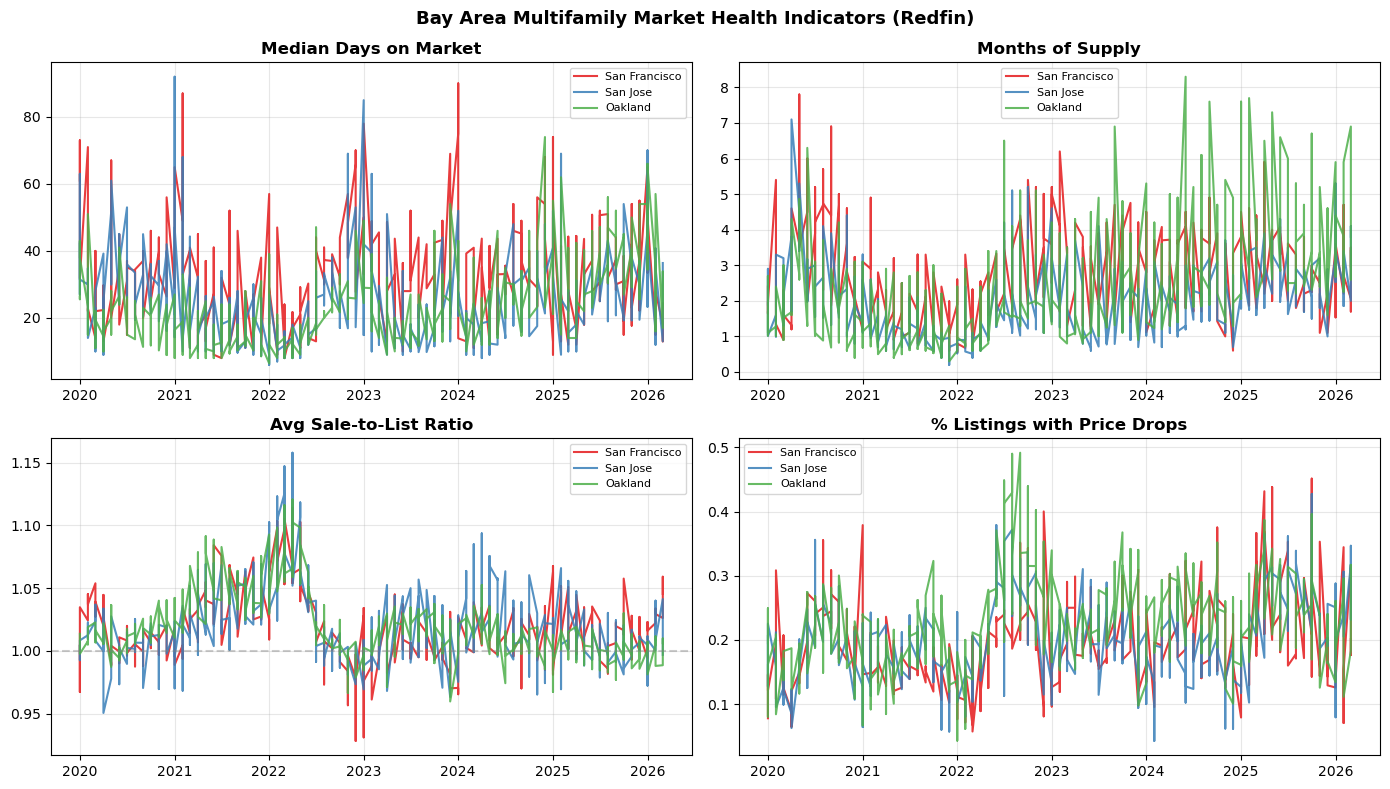

In [9]:
# Supplement ZHVI forecast with Redfin transaction-level signals
redfin = pd.read_csv(DATA / 'redfin_metro_bayarea_multifamily.csv')
redfin['PERIOD_BEGIN'] = pd.to_datetime(redfin['PERIOD_BEGIN'])

# Focus on SF + SJ + Oakland metros, Condo/Co-op + 2-4 unit MF
key_metros = ['San Francisco, CA metro area', 'San Jose, CA metro area', 'Oakland, CA metro area']
redfin_key = redfin[
    redfin['REGION'].isin(key_metros) &
    (redfin['PERIOD_BEGIN'] >= '2020-01-01')
].copy()

# Key leading indicators: DOM, months of supply, price cuts, sale-to-list ratio
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

metrics = [
    ('MEDIAN_DOM', 'Median Days on Market', axes[0, 0]),
    ('MONTHS_OF_SUPPLY', 'Months of Supply', axes[0, 1]),
    ('AVG_SALE_TO_LIST', 'Avg Sale-to-List Ratio', axes[1, 0]),
    ('PRICE_DROPS', '% Listings with Price Drops', axes[1, 1]),
]

colors_m = {'San Francisco, CA metro area': '#e41a1c',
             'San Jose, CA metro area': '#377eb8',
             'Oakland, CA metro area': '#4daf4a'}

for col, title, ax in metrics:
    if col not in redfin_key.columns:
        ax.set_title(f'{title}\n(no data)')
        continue
    for metro, color in colors_m.items():
        subset = redfin_key[redfin_key['REGION'] == metro].sort_values('PERIOD_BEGIN')
        if subset.empty:
            continue
        ax.plot(subset['PERIOD_BEGIN'], subset[col],
                label=metro.replace(', CA metro area',''),
                color=color, linewidth=1.5, alpha=0.85)
    ax.set_title(title, fontweight='bold')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
    if col == 'AVG_SALE_TO_LIST':
        ax.axhline(1.0, color='gray', linestyle='--', alpha=0.4)

plt.suptitle('Bay Area Multifamily Market Health Indicators (Redfin)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT / 'charts/redfin_market_health.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
print('=== PROJECT SUMMARY ===')
print('\nNotebooks completed:')
print('  01_market_selection.ipynb — Zip-code ranking by investment attractiveness')
print('  02_distressed_signals.ipynb  — SF distressed operator identification')
print('  03_price_forecasting.ipynb   — SARIMA 12-month price forecasts')
print('\nOutputs generated:')

import os
for root, dirs, files in os.walk('../outputs'):
    for f in files:
        path = os.path.join(root, f)
        size = os.path.getsize(path)
        print(f'  {path} ({size/1024:.0f} KB)')

=== PROJECT SUMMARY ===

Notebooks completed:
  01_market_selection.ipynb — Zip-code ranking by investment attractiveness
  02_distressed_signals.ipynb  — SF distressed operator identification
  03_price_forecasting.ipynb   — SARIMA 12-month price forecasts

Outputs generated:
  ../outputs/maps/market_selection_map.html (8842 KB)
  ../outputs/tables/market_selection_ranked.csv (73 KB)
  ../outputs/tables/distress_scores_ranked.csv (56 KB)
  ../outputs/tables/price_forecasts_12mo.csv (0 KB)
  ../outputs/charts/factor_heatmap_top10.png (116 KB)
  ../outputs/charts/county_price_history.png (185 KB)
  ../outputs/charts/opportunity_matrix.png (282 KB)
  ../outputs/charts/permits_over_time.png (46 KB)
  ../outputs/charts/evictions_by_neighborhood.png (117 KB)
  ../outputs/charts/ellis_act.png (79 KB)
  ../outputs/charts/price_forecasts.png (400 KB)
  ../outputs/charts/evictions_overview.png (87 KB)
  ../outputs/charts/sf_decomposition.png (217 KB)
  ../outputs/charts/redfin_market_health.png